# Quantified Self Project - _LaLaLand_


### by Thomas Schuff


## Introduction:


For this Quantified Self project, I analyzed my personal Apple Music listening
history over the last year(ish). Music is a huge part of my daily routine, and
understanding how my listening behavior changes oover time is meaningful to me
both personally and academically.


### Dataset Overview

My project uses **two tables**:

1. **Apple Music Play Activity (CSV)**
   - Contains timestamped events for every time I played, paused, or resumed a
     song
   - After cleaning and collapsing duplicate events, this table provides daily
     listening history
2. **Weekday Table (CSV)**
   - Maps each date to its corresponding day of the week


### Attributes

Accross the merged dataset, I analyzed the following attributes:

- "Date" --> The calendar date
- "Listen Count" --> the number of unique listening "sessions" per day
- "Day of Week" --> the day of the week lol
- "Is Weekend" --> class label (0 = weekday, 1 = weekend)
- "Month" --> numeric month
- "Rolling Average" --> 7-day rolling average of listening activity


### Classification Task

I attempt to **predict whether a given day is a weekday or weekend** based on
listening behavior.  
I use k-Nearest Neighbors (kNN) classification to accomplish this.


### Hypotheses

I test two hypotheses:

1. **Weekday vs. Weekend Listening**
   - $H_{null}$: Mean weekday listening count $=$ mean weekend listening count
   - $H_{alt}$: Mean weekday listening count $\neq$ mean weekend listening count

2. **Monthly Differences**
   - $H_{null}$: All months have the same mean listening count
   - $H_{alt}$: At least one month differs

These tests help reveal whether my listening behavior changes across the week or
across months.


---


## Data Preparation:


In this section, I load my two datasets, clean the Apple Music activity table,
collapse duplicate events into listening sessions, compute daily listening
counts, and merge with the weekday table.


In [1]:
import pandas as pd
import new_utils
import matplotlib.pyplot as plt

%cd /Users/schufft/Library/CloudStorage/OneDrive-GonzagaUniversity/Classes/Spring 2026/CPSC 222 - Data Science/quantified-self-project


# Load datasets
activity_raw = new_utils.load_activity_data(
    "lalaland/dataset files/Apple Music Play Activity.csv"
)
weekday_df = new_utils.load_weekday_table("lalaland/dataset files/weekday_table.csv")

# Clean activity data
activity_clean = new_utils.clean_activity_data(activity_raw)

# Compute daily listening counts
daily_df = new_utils.calc_daily_counts(activity_clean)

# Merge with weekday table
merged_df = new_utils.merge_with_weekday(daily_df, weekday_df)

# Add additional features
merged_df = new_utils.add_month(merged_df)
merged_df = new_utils.add_rolling_average(merged_df)
merged_df = new_utils.add_weekend_flag(merged_df)

/Users/schufft/Library/CloudStorage/OneDrive-GonzagaUniversity/Classes/Spring 2026/CPSC 222 - Data Science/quantified-self-project


/Users/schufft/Library/CloudStorage/OneDrive-GonzagaUniversity/Classes/Spring 2026/CPSC 222 - Data Science/quantified-self-project/lalaland/new_utils.py:32: DtypeWarning: Columns (15,16,23,24,25,31,34,53,61,62,64,65,88,90,93,94,97,99,101,103,104,112,113,116,117,123,130,132,135,136,140) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(filename)
/Users/schufft/Library/CloudStorage/OneDrive-GonzagaUniversity/Classes/Spring 2026/CPSC 222 - Data Science/quantified-self-project/lalaland/new_utils.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Song Name", "Date"], group_keys=False).apply(calc_song_session)


---


## Exploratory Data Analysis:


Here I explore trends in my listening behavior using summary statistics and
visualizations.


In [2]:
# Summary Statistics
merged_df.describe()

,Date,Listen Count,Month,Rolling Average,Is Weekend
count,291,291.000000,291.000000,285.000000,291.00000
mean,2025-11-15 03:32:47.010309376,109.336770,6.835052,110.346366,0.28866
min,2025-05-29 00:00:00,1.000000,1.000000,30.571429,0.00000
25%,2025-09-02 12:00:00,69.000000,3.000000,92.714286,0.00000
50%,2025-11-16 00:00:00,99.000000,8.000000,110.428571,0.00000
75%,2026-01-28 12:00:00,146.500000,10.000000,130.714286,1.00000
max,2026-04-12 00:00:00,281.000000,12.000000,174.142857,1.00000
std,NaN,59.043555,3.741695,27.917058,0.45392


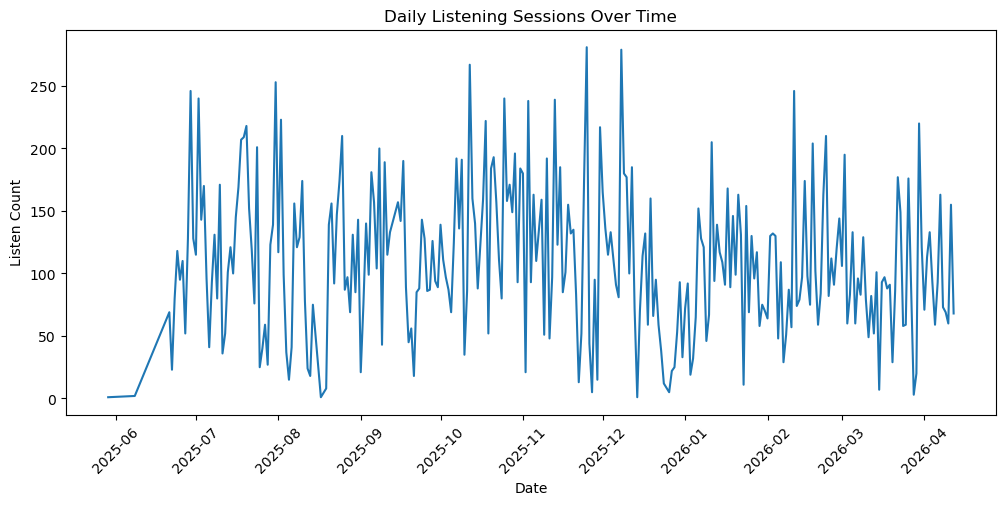

In [3]:
# Plot Daily Counts
plt.figure(figsize=(12, 5))
plt.plot(merged_df["Date"], merged_df["Listen Count"])
plt.title("Daily Listening Sessions Over Time")
plt.xlabel("Date")
plt.ylabel("Listen Count")
plt.xticks(rotation=45)
plt.show()

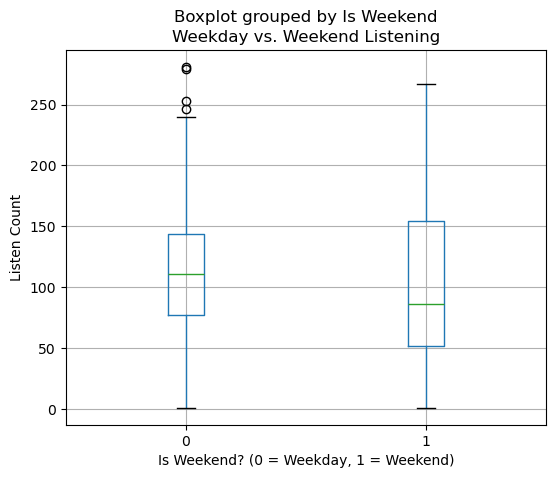

In [4]:
# Boxplot for Weekday vs. Weekend
merged_df.boxplot(column="Listen Count", by="Is Weekend", figsize=(6, 5))
plt.title("Weekday vs. Weekend Listening")
plt.xlabel("Is Weekend? (0 = Weekday, 1 = Weekend)")
plt.ylabel("Listen Count")
plt.show()

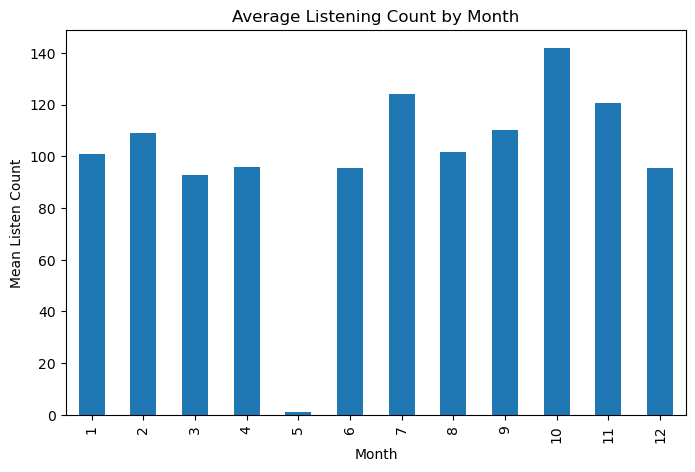

In [5]:
# Monthly Trend
merged_df.groupby("Month")["Listen Count"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Listening Count by Month")
plt.xlabel("Month")
plt.ylabel("Mean Listen Count")
plt.show()

---


## Hypothesis Testing


I performed two statistical tests to detect any differences in my listening
behavior across days of the week and across months.


In [6]:
# t-Test
t_stat, p_val = new_utils.t_test_weekday_vs_weekend(merged_df)
print(f"t-Statistic: {t_stat}, p-Value: {p_val}")

t-Statistic: 1.6924751474500999, p-Value: 0.09292052483833946


### Interpretation

- If $p < 0.05$, I reject the null hypothesis and conclude that weekday and
  weekend listening differ.
- If $p \geq 0.05$, I fail to reject the null hypothesis.


In [7]:
# ANOVA
F_stat, pval_anova = new_utils.anova_monthly(merged_df)
print(f"F-Statistic: {F_stat}, p-Value: {pval_anova}")

F-Statistic: 2.1018530682117924, p-Value: 0.02033231304273


### Interpretation

- If p < 0.05, at least one month differs significantly.
- If p ≥ 0.05, monthly listening patterns are statistically similar.


---


## Classification: Predicting Weekday vs. Weekend


I trained a k‑Nearest Neighbors classifier to predict whether a day is a weekday
or weekend based on listening behavior.


In [8]:
# Prepare the Data

# Choose features
features = ["Listen Count", "Rolling Average", "Month"]
merged_df = merged_df.dropna()
X, y = new_utils.prep_classification(merged_df, features, "Is Weekend")

In [9]:
# Train the kNN Model
knn, X_test, y_test, y_pred, acc = new_utils.train_knn_classifier(X, y, k=5)

### Interpretation

- Accuracy indicates how well the model predicts weekday vs weekend.
- I compare this to a baseline (e.g., majority class).
- I discuss whether listening behavior is a strong predictor of day type.


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

print("kNN Classification Results")
print(f"Accuracy: {acc:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm, "\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Weekday", "Weekend"]))


# Show first few predictions
results_df = pd.DataFrame(
    {
        "Actual": [new_utils.convert_label(act_val) for act_val in y_test],
        "Predicted": [new_utils.convert_label(pred_val) for pred_val in y_pred],
    }
)

print("\nSample Predictions:")
print(results_df.head(50))

kNN Classification Results
Accuracy: 0.7018

Confusion Matrix:
[[39  4]
 [13  1]] 

Classification Report:
              precision    recall  f1-score   support

     Weekday       0.75      0.91      0.82        43
     Weekend       0.20      0.07      0.11        14

    accuracy                           0.70        57
   macro avg       0.47      0.49      0.46        57
weighted avg       0.61      0.70      0.65        57


Sample Predictions:
     Actual Predicted
0   Weekday   Weekday
1   Weekend   Weekday
2   Weekday   Weekday
3   Weekday   Weekday
4   Weekday   Weekday
5   Weekday   Weekday
6   Weekend   Weekday
7   Weekday   Weekday
8   Weekday   Weekday
9   Weekday   Weekday
10  Weekend   Weekday
11  Weekday   Weekday
12  Weekday   Weekday
13  Weekday   Weekday
14  Weekday   Weekday
15  Weekday   Weekday
16  Weekday   Weekday
17  Weekday   Weekday
18  Weekday   Weekday
19  Weekday   Weekday
20  Weekday   Weekday
21  Weekday   Weekday
22  Weekday   Weekday
23  Weekday   Wee

---


## Conclusion


In this project, I analyzed my Apple Music listening behavior over several
months. I found that:

- (Fill in your t‑test result)
- (Fill in your ANOVA result)
- (Fill in your kNN accuracy)

I also discussed potential impacts, limitations, and future improvements, such
as incorporating mood, location, or activity data to enrich the analysis.

This project helped me understand my own habits and apply the full data science
pipeline — cleaning, EDA, hypothesis testing, and classification — to a dataset
that is personally meaningful.


---
